In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.util import add_cyclic_point

In [2]:
ds_mslp = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week5\mslp.mon.mean.nc")
ds_mslp = ds_mslp.sel(time = slice('1979', '2019')) 
ds_mslp.load()

<xarray.Dataset>
Dimensions:    (lat: 73, lon: 144, time: 492, nbnds: 2)
Coordinates:
  * lat        (lat) float32 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon        (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] 1979-01-01 1979-02-01 ... 2020-01-01
    mslp       (time, lat, lon) float32 1.022e+05 1.022e+05 ... 1.008e+05
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2002/03 by Hoop (netCDF2.3)\nConverted to chunked...

In [3]:
#make anomaly
mslp_clim = ds_mslp.groupby('time.month').mean(dim = 'time')
mslp_anom = ds_mslp.groupby('time.month') - mslp_clim

In [4]:
mslp_anom

<xarray.Dataset>
Dimensions:  (lat: 73, lon: 144, time: 492)
Coordinates:
  * lat      (lat) float32 90.0 87.5 85.0 82.5 80.0 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    mslp     (time, lat, lon) float32 895.1 895.1 895.1 ... 768.1 768.1 768.1

計算nino34

In [5]:
ds_sst_2 = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week6\sst.mnmean.nc")
#ds_sst = ds_sst.sel(time = slice('1979', '2019')) 
ds_sst_2.load()

<xarray.Dataset>
Dimensions:    (lat: 89, lon: 180, time: 2030, nbnds: 2)
Coordinates:
  * lat        (lat) float32 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon        (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1854-01-01 1854-02-01 ... 2023-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
    sst        (time, lat, lon) float32 -1.8 -1.8 -1.8 -1.8 ... nan nan nan nan
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    creator_url_original:      https://www.ncei.noaa.gov
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2023-03-04

In [6]:
#make anomaly
sst_clim = ds_sst_2.sst.groupby('time.month').mean(dim = 'time')
sst_anom = ds_sst_2.sst.groupby('time.month') - sst_clim

In [7]:
#detrend 移掉趨勢 
#區分出variability跟trend。
from scipy.signal import detrend
sst_anom_detrended = xr.apply_ufunc(detrend, sst_anom.fillna(0),
                                    kwargs={'axis': 0}).where(~sst_anom.isnull())

In [8]:
sst_anom_nino34 = sst_anom_detrended.sel(lat = slice(5, -5), lon = slice(190, 240)) 
sst_anom_nino34_mean = sst_anom_nino34.mean(dim = ('lon', 'lat'))
oni34 = sst_anom_nino34_mean.rolling(time = 3, center=True).mean()
ds_oni = oni34.sel(time=slice('1979', '2019'))  

In [9]:
ds_oni

<xarray.DataArray 'sst' (time: 492)>
array([ 3.64065692e-02,  6.10422492e-02,  1.61984026e-01,  1.70094669e-01,
        1.02358282e-01, -5.66177592e-02,  5.08555770e-03,  1.81997418e-01,
        3.87770265e-01,  5.17657936e-01,  5.73489130e-01,  6.47904992e-01,
        5.92190504e-01,  4.39135253e-01,  2.89184213e-01,  2.59172529e-01,
        3.46379638e-01,  3.49849164e-01,  2.12849110e-01,  3.80959138e-02,
       -1.46320909e-02,  7.65385926e-02,  1.59621388e-01,  5.75096309e-02,
       -1.53590918e-01, -3.69609803e-01, -3.73874873e-01, -3.36505502e-01,
       -2.54749537e-01, -2.90474474e-01, -2.61728227e-01, -1.85301751e-01,
       -5.95039725e-02, -1.91008504e-02, -4.40528095e-02,  3.18648294e-02,
        8.23744088e-02,  2.02217370e-01,  2.80456483e-01,  5.00764966e-01,
        6.58095837e-01,  7.12310016e-01,  8.17993581e-01,  1.12536216e+00,
        1.67427564e+00,  2.06986618e+00,  2.27955294e+00,  2.33163691e+00,
        2.30473852e+00,  2.04278231e+00,  1.63264108e+00,  1.30782008e+00,
        1.05809581e+00,  7.09782600e-01,  3.38143080e-01, -2.83224583e-02,
       -3.64330173e-01, -7.07114220e-01, -9.01845396e-01, -8.10435474e-01,
       -4.78896201e-01, -2.99067944e-01, -2.50540584e-01, -4.15984809e-01,
       -5.20082593e-01, -4.61690843e-01, -2.84460813e-01, -1.09675229e-01,
       -1.53553009e-01, -4.65409160e-01, -8.22539449e-01, -1.04914308e+00,
       -9.28210735e-01, -7.34225988e-01, -6.87860191e-01, -7.72563338e-01,
       -7.90211558e-01, -6.45032525e-01, -4.74240869e-01, -4.14868057e-01,
...
       -1.17331564e-01, -3.80321592e-02, -5.60050532e-02, -2.24219084e-01,
       -4.17403758e-01, -4.47377920e-01, -2.01830611e-01,  1.24591574e-01,
        3.15578461e-01,  2.67050415e-01,  1.68363810e-01,  1.76525280e-01,
        3.56558889e-01,  6.14917159e-01,  7.33644187e-01,  6.94866419e-01,
        5.60404360e-01,  4.95568991e-01,  6.07915640e-01,  7.85047293e-01,
        1.04136205e+00,  1.29453039e+00,  1.64425325e+00,  1.97232056e+00,
        2.28558969e+00,  2.54805517e+00,  2.67743945e+00,  2.67849159e+00,
        2.49128151e+00,  2.15654588e+00,  1.65740371e+00,  1.02897072e+00,
        5.05996644e-01,  4.98852730e-02, -2.26880521e-01, -4.19521093e-01,
       -4.95270669e-01, -5.57633042e-01, -5.60022891e-01, -5.25049984e-01,
       -3.36135507e-01, -1.48411378e-01,  1.13311276e-01,  2.76290357e-01,
        3.99611413e-01,  4.19281572e-01,  2.66221702e-01,  2.72691250e-04,
       -2.62429446e-01, -5.32815158e-01, -7.45312810e-01, -9.48505342e-01,
       -9.20409858e-01, -8.43194366e-01, -6.35260284e-01, -4.24478471e-01,
       -1.15584992e-01,  1.01281747e-01,  2.18509480e-01,  3.48154962e-01,
        6.18325591e-01,  8.86686802e-01,  9.98711467e-01,  8.51213634e-01,
        7.58535266e-01,  7.47366130e-01,  7.88646877e-01,  7.50998676e-01,
        6.56201959e-01,  5.67491949e-01,  4.12715375e-01,  2.62695551e-01,
        3.20763528e-01,  4.80514228e-01,  6.16710901e-01,  5.84712684e-01],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

計算nino4

In [5]:
ds_sst_2 = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week6\sst.mnmean.nc")
#ds_sst = ds_sst.sel(time = slice('1979', '2019')) 
ds_sst_2.load()

<xarray.Dataset>
Dimensions:    (lat: 89, lon: 180, time: 2030, nbnds: 2)
Coordinates:
  * lat        (lat) float32 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon        (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1854-01-01 1854-02-01 ... 2023-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
    sst        (time, lat, lon) float32 -1.8 -1.8 -1.8 -1.8 ... nan nan nan nan
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    creator_url_original:      https://www.ncei.noaa.gov
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2023-03-04

In [6]:
#make anomaly
sst_clim = ds_sst_2.sst.groupby('time.month').mean(dim = 'time')
sst_anom = ds_sst_2.sst.groupby('time.month') - sst_clim

In [7]:
#detrend 移掉趨勢 
#區分出variability跟trend。
from scipy.signal import detrend
sst_anom_detrended = xr.apply_ufunc(detrend, sst_anom.fillna(0),
                                    kwargs={'axis': 0}).where(~sst_anom.isnull())

In [8]:
sst_anom_nino4 = sst_anom_detrended.sel(lat=slice(5, -5), lon = slice(160, 210)) #150w 160e
sst_anom_nino4_mean = sst_anom_nino4.mean(dim = ('lon', 'lat'))
oni4 = sst_anom_nino4_mean.rolling(time = 3, center=True).mean()  
ds_oni4 = oni4.sel(time = slice('1979', '2019'))  

In [9]:
ds_oni4

<xarray.DataArray 'sst' (time: 492)>
array([ 0.18867335,  0.2541216 ,  0.24986097,  0.22274372,  0.16225255,
        0.12151786,  0.07087289,  0.05640803,  0.06520452,  0.23410529,
        0.39571375,  0.54022217,  0.60301757,  0.5834397 ,  0.52173615,
        0.48570818,  0.4895552 ,  0.4698639 ,  0.32327855,  0.18267113,
        0.16893578,  0.24190132,  0.29181814,  0.22227076,  0.15395564,
        0.11711264,  0.00263332, -0.1263499 , -0.24736688, -0.29794407,
       -0.30958092, -0.24300456, -0.12617047, -0.01217792,  0.0600143 ,
        0.14039987,  0.16464725,  0.22899167,  0.3609867 ,  0.5473219 ,
        0.6852411 ,  0.63850504,  0.5741767 ,  0.54038763,  0.7245502 ,
        0.8679773 ,  0.8987607 ,  0.77197385,  0.6757564 ,  0.5909176 ,
        0.48689955,  0.427528  ,  0.3664171 ,  0.27949834,  0.12748434,
       -0.1281977 , -0.33376247, -0.55466145, -0.6002215 , -0.61132574,
       -0.5244676 , -0.51719344, -0.51954776, -0.5486078 , -0.5131725 ,
       -0.40242285, -0.31044418, -0.22798371, -0.2739591 , -0.3905313 ,
       -0.5615713 , -0.56819123, -0.5181999 , -0.52343297, -0.6722817 ,
       -0.7646324 , -0.7269989 , -0.567786  , -0.3965703 , -0.24297637,
       -0.13530633, -0.07808346, -0.02475941, -0.01294812,  0.00601194,
        0.04043982,  0.02546399, -0.00813058, -0.00503091,  0.09844276,
        0.2644722 ,  0.4028824 ,  0.5096059 ,  0.5959881 ,  0.60143435,
        0.58703554,  0.6119998 ,  0.6738722 ,  0.61683834,  0.5093932 ,
...
       -0.80845344, -0.83358073, -0.74401116, -0.58927166, -0.45858377,
       -0.31483766, -0.1852448 ,  0.04809725,  0.2452455 ,  0.43458652,
        0.48851466,  0.40574533,  0.23898314,  0.05713032, -0.072001  ,
       -0.11955421, -0.13271675, -0.05989721, -0.031076  ,  0.02264073,
        0.05178428,  0.11696538,  0.16978085,  0.15814494,  0.07835737,
        0.0708053 ,  0.19480257,  0.38504398,  0.5352843 ,  0.5891604 ,
        0.53889114,  0.48489007,  0.48869962,  0.601988  ,  0.7407627 ,
        0.8291786 ,  0.8856647 ,  0.91819465,  0.97730607,  1.0679927 ,
        1.0881716 ,  1.111097  ,  1.0957274 ,  1.14714   ,  1.1960996 ,
        1.265588  ,  1.3987362 ,  1.4753351 ,  1.4896276 ,  1.4024633 ,
        1.3178749 ,  1.1743841 ,  0.943498  ,  0.72652024,  0.5438777 ,
        0.3846419 ,  0.17845534, -0.00959742, -0.15410103, -0.16410552,
       -0.10533546, -0.00299117,  0.06622137,  0.15557685,  0.24542403,
        0.3772276 ,  0.4613135 ,  0.46240887,  0.34035182,  0.18709692,
        0.00771467, -0.18319719, -0.30020776, -0.29960433, -0.18506789,
       -0.01667871,  0.1498981 ,  0.32197735,  0.41306978,  0.5466281 ,
        0.65904295,  0.89730954,  1.0339181 ,  1.1088125 ,  1.0056685 ,
        0.91510904,  0.84089106,  0.7770442 ,  0.72082615,  0.72378135,
        0.8214149 ,  0.8937425 ,  0.88115805,  0.87947786,  0.89533395,
        0.95899105,  0.95296943], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

計算nino4和mslp的相關性

In [10]:
pt_mslp = mslp_anom.sel(lat = 0,lon = 360-180,method = 'nearest')

c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(


In [12]:
pt_mslp

<xarray.Dataset>
Dimensions:  (time: 492)
Coordinates:
    lat      float32 0.0
    lon      float32 180.0
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    mslp     (time) float32 -16.07 20.98 -22.66 16.12 ... 45.41 4.656 75.17

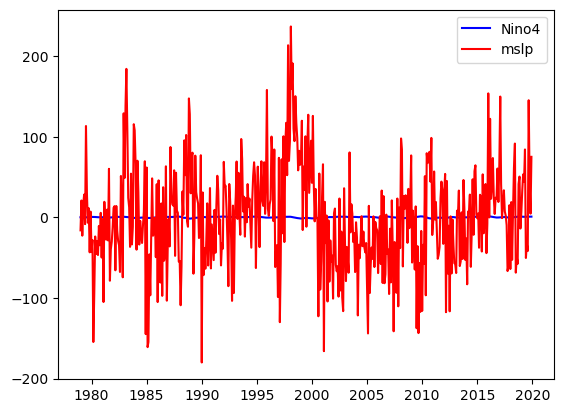

In [13]:
#line plot 
plt.plot(ds_oni4['time'],ds_oni4,'b')
plt.plot(pt_mslp['time'],pt_mslp["mslp"],'r')
plt.legend(['Nino4','mslp'])

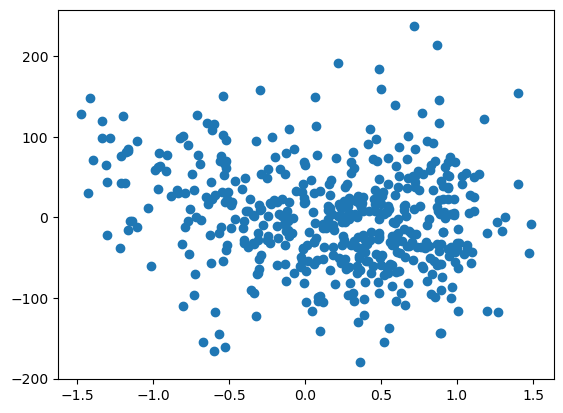

In [14]:
#scatter plot 
plt.scatter(ds_oni4,pt_mslp["mslp"])
plt.show()

In [15]:
#numpy correlation function
R=np.corrcoef(ds_oni4,pt_mslp["mslp"])
R

array([[ 1.        , -0.17247215],
       [-0.17247215,  1.        ]])

In [16]:
corr=R[0,1]
corr

-0.17247215197513338

In [17]:
#scipy correlation function 
(rvalue, pvalue) =  scipy.stats.pearsonr(ds_oni4,pt_mslp['mslp'])
rvalue

-0.1724721519751331

In [18]:
pvalue

0.00012068256142305318

Text(1.0, 1.0, 'R= -0.17*')

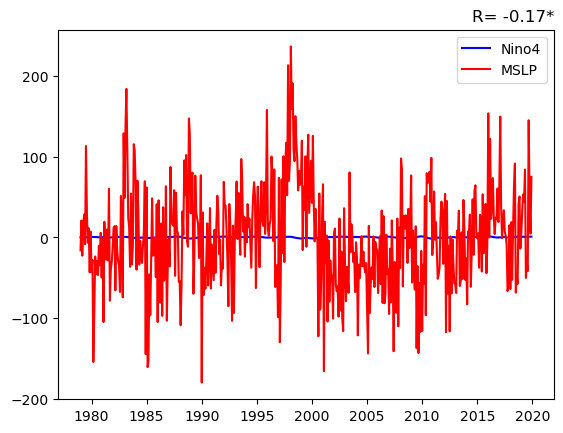

In [33]:
plt.plot(ds_oni4['time'],ds_oni4,'b')
plt.plot(pt_mslp['time'],pt_mslp['mslp'],'r')
plt.legend(['Nino4','MSLP'])

rvalue_2 = round(rvalue, 2)
stuff_in_string = f"R= {rvalue_2}*"

#print(stuff_in_string)
plt.title(stuff_in_string,loc='right')

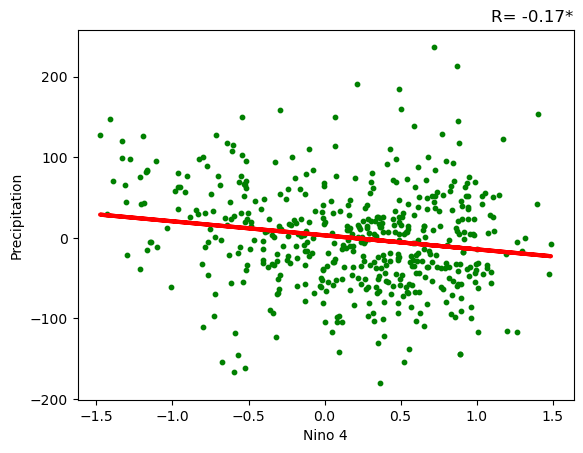

In [34]:
plt.scatter(ds_oni4,pt_mslp['mslp'], s=10, color="green")
plt.title(stuff_in_string,loc='right')

m, b = np.polyfit(ds_oni4,pt_mslp['mslp'], 1)
plt.plot(ds_oni4, m*ds_oni4 + b, color="red",linewidth=3)
plt.xlabel("Nino 4")
plt.ylabel("Precipitation")

plt.show()

In [26]:
#Method II: scipy
from scipy.stats import pearsonr

In [27]:
nx=len(ds_mslp['lon'])
ny=len(ds_mslp['lat'])

p_array=np.zeros((ny,nx))
r_array=np.zeros((ny,nx))

for i in range(nx):
    for j in range(ny):
        r,p = pearsonr(ds_oni4,ds_mslp['mslp'][:,j,i])
        r_array[j,i]=r
        p_array[j,i]=p
r_array.shape

(73, 144)

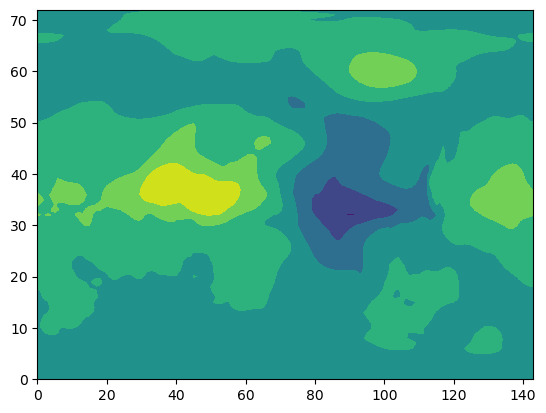

In [28]:
plt.contourf(r_array)

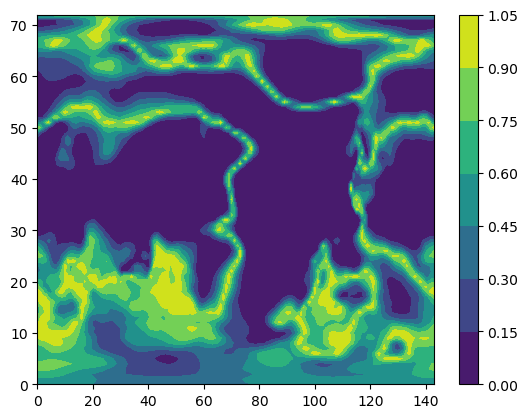

In [29]:
plt.contourf(p_array)
plt.colorbar()

In [30]:
mask_sig=np.where(p_array<0.001,r_array,np.nan)

Text(1.0, 1.0, '99.9% sig.')

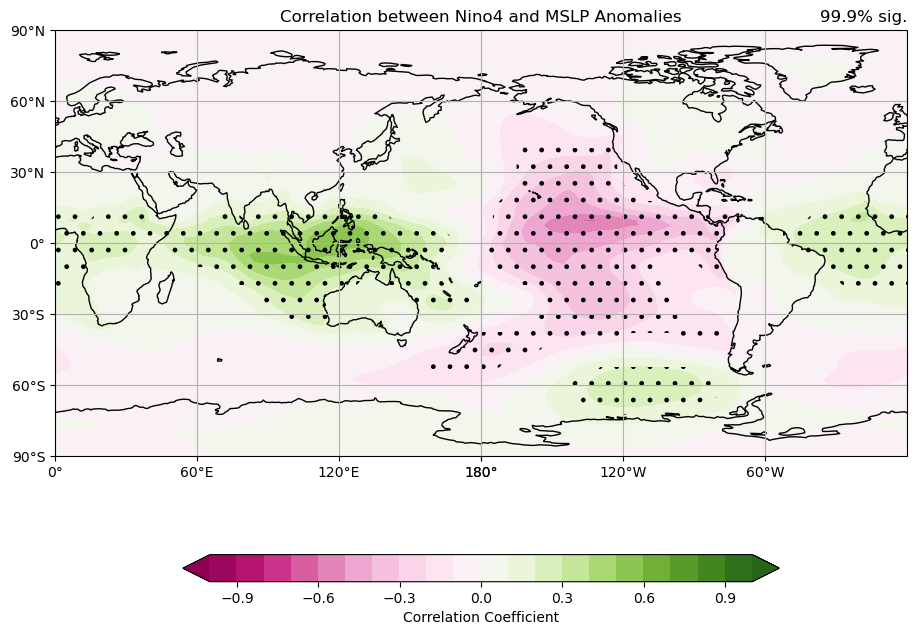

In [32]:
clevs=np.arange(-1,1.1,0.1)

fig = plt.figure(figsize=(11,8.5))

# Set the axes using the specified map projection
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

# Add cyclic point
data=r_array
data,lon=add_cyclic_point(data,coord=ds_mslp['lon'])
mask_data,lons=add_cyclic_point(mask_sig,coord=ds_mslp['lon'])

# Make a filled contour plot
cs=ax.contourf(lon,ds_mslp['lat'],
            data,clevs,
            transform=ccrs.PlateCarree(),
            cmap='PiYG',extend='both')

ax.contourf(lon,ds_mslp['lat'],mask_data,[0,1],
            transform = ccrs.PlateCarree(),colors='None',
            hatches=['.','.'],extend='both',alpha=0)

# Add coastlines
ax.coastlines()

# Add gridlines
ax.gridlines()

# Define the xticks for longtitude 
ax.set_xticks(np.arange(-180,181,60),crs=ccrs.PlateCarree())
lon_formatter=cticker.LongitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)

# Define ytick for latitude
ax.set_yticks(np.arange(-90,91,30),crs=ccrs.PlateCarree())
lat_formatter=cticker.LatitudeFormatter()
ax.yaxis.set_major_formatter(lat_formatter)

# Call colorbar
cbar=plt.colorbar(cs,orientation='horizontal',shrink=0.7,
                 label='Correlation Coefficient')

# Add title
plt.title('Correlation between Nino4 and MSLP Anomalies')
plt.title('99.9% sig.',loc='right')

In [25]:
#Method I: xarray
r_map=xr.corr(ds_oni4,ds_mslp['mslp'],dim='time')
r_map

<xarray.DataArray (lat: 73, lon: 144)>
array([[-0.034318  , -0.034318  , -0.034318  , ..., -0.034318  ,
        -0.034318  , -0.034318  ],
       [-0.0255703 , -0.02559135, -0.02570518, ..., -0.02560441,
        -0.02555191, -0.02547902],
       [-0.01787607, -0.01790496, -0.01802926, ..., -0.01877448,
        -0.01838888, -0.0180979 ],
       ...,
       [-0.08087884, -0.07899213, -0.07696496, ..., -0.08562673,
        -0.08423717, -0.08263414],
       [-0.07970128, -0.07793345, -0.07598342, ..., -0.08411963,
        -0.08281636, -0.08134865],
       [-0.01369824, -0.01369824, -0.01369824, ..., -0.01369824,
        -0.01369824, -0.01369824]])
Coordinates:
  * lat      (lat) float32 90.0 87.5 85.0 82.5 80.0 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5

In [ ]:
clevs=np.arange(-1,1.1,0.1)

fig = plt.figure(figsize=(11,8.5))

# Set the axes using the specified map projection
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

# Add cyclic point
data=r_map
data,lon=add_cyclic_point(r_map,coord=ds_anoms['lon'])

# Make a filled contour plot
cs=ax.contourf(lon,ds_anoms['lat'],
            data,clevs,
            transform=ccrs.PlateCarree(),
            cmap='PiYG',extend='both')

# Add coastlines
ax.coastlines()

# Add gridlines
ax.gridlines()

# Define the xticks for longtitude 
ax.set_xticks(np.arange(-180,181,60),crs=ccrs.PlateCarree())
lon_formatter=cticker.LongitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)

# Define ytick for latitude
ax.set_yticks(np.arange(-90,91,30),crs=ccrs.PlateCarree())
lat_formatter=cticker.LatitudeFormatter()
ax.yaxis.set_major_formatter(lat_formatter)

# Call colorbar
cbar=plt.colorbar(cs,orientation='horizontal',shrink=0.7,
                 label='Correlation Coefficient')

# Add title
plt.title('Correlation between Nino3.4 and Precipitation Anomalie')

Class examples test

In [12]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.util import add_cyclic_point

In [13]:
#read nino3.4 index
#ds_oni = xr.open_dataset("ENSOindex.oni.1960-2020.nc")
#ds_oni = ds_oni.sel(time=slice('1979', '2019'))
#ds_oni['sst'].plot()

#read SST
ds_sst = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week6\sst.mnmean.nc")
ds_sst = ds_sst.sel(time = slice('1979', '2019')) 
ds_sst.load()
ds_sst

#read precipitation
ds_prec = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week5\precip.mon.mean.nc")
ds_prec = ds_prec.sel(time = slice('1979', '2019')) 
ds_prec.load()
ds_prec

<xarray.Dataset>
Dimensions:    (lat: 72, lon: 144, time: 492, nv: 2)
Coordinates:
  * lat        (lat) float32 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon        (lon) float32 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) datetime64[ns] 1979-01-01 1979-02-01 ... 2020-01-01
    lat_bnds   (lat, nv) float32 -90.0 -87.5 -87.5 -85.0 ... 85.0 87.5 87.5 90.0
    lon_bnds   (lon, nv) float32 0.0 2.5 2.5 5.0 5.0 ... 355.0 357.5 357.5 360.0
    precip     (time, lat, lon) float32 0.0 0.0 0.0 0.0 ... 0.1305 0.1327 0.1341
Attributes: (12/18)
    Conventions:           CF-1.0
    curator:               Dr. Jian-Jian Wang\nESSIC, University of Maryland ...
    citation:              Adler, R.F., G.J. Huffman, A. Chang, R. Ferraro, P...
    title:                 GPCP Version 2.3 Combined Precipitation Dataset (F...
    platform:              NOAA POES (Polar Orbiting Environmental Satellites)
    source_obs:            CDR RSS SSMI/SSMIS Tbs over ocean \nCDR SSMI/SSMIS...
    ...                    ...
    source:                https://www.ncei.noaa.gov/data/global-precipitatio...
    source_documentation:  https://www.ncdc.noaa.gov/cdr/atmospheric/precipit...
    NCO:                   4.6.9
    history:               Generated at NOAA/ESRL PSD Sep 9 2016 based on dat...
    References:            http://www.psl.noaa.gov/data/gridded/data.gpcp.html
    data_comment:          Interim data covers 2023/01 through latest.

In [14]:
# Make anomalies
ds_climo = ds_prec.groupby('time.month').mean()
ds_anoms = ds_prec.groupby('time.month')-ds_climo
ds_anoms

<xarray.Dataset>
Dimensions:   (lat: 72, lon: 144, time: 492, nv: 2)
Coordinates:
  * lat       (lat) float32 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon       (lon) float32 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * time      (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month     (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: nv
Data variables:
    lat_bnds  (time, lat, nv) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    lon_bnds  (time, lon, nv) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precip    (time, lat, lon) float32 -0.02191 -0.03154 ... -0.2816 -0.2292

In [15]:
# choose one point timeseries
pt = ds_anoms.sel(lat = 0,lon = 360-180,method = 'nearest')

c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(


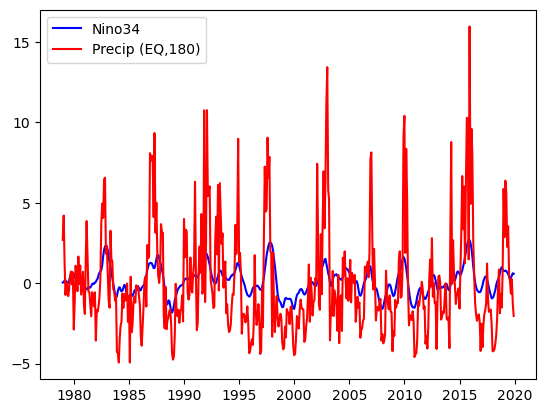

In [16]:
#line plot 
plt.plot(ds_oni['time'],ds_oni,'b')
plt.plot(pt['time'],pt['precip'],'r')
plt.legend(['Nino34','Precip (EQ,180)'])

In [17]:
ds_oni

<xarray.DataArray 'sst' (time: 492)>
array([ 3.64065692e-02,  6.10422492e-02,  1.61984026e-01,  1.70094669e-01,
        1.02358282e-01, -5.66177592e-02,  5.08555770e-03,  1.81997418e-01,
        3.87770265e-01,  5.17657936e-01,  5.73489130e-01,  6.47904992e-01,
        5.92190504e-01,  4.39135253e-01,  2.89184213e-01,  2.59172529e-01,
        3.46379638e-01,  3.49849164e-01,  2.12849110e-01,  3.80959138e-02,
       -1.46320909e-02,  7.65385926e-02,  1.59621388e-01,  5.75096309e-02,
       -1.53590918e-01, -3.69609803e-01, -3.73874873e-01, -3.36505502e-01,
       -2.54749537e-01, -2.90474474e-01, -2.61728227e-01, -1.85301751e-01,
       -5.95039725e-02, -1.91008504e-02, -4.40528095e-02,  3.18648294e-02,
        8.23744088e-02,  2.02217370e-01,  2.80456483e-01,  5.00764966e-01,
        6.58095837e-01,  7.12310016e-01,  8.17993581e-01,  1.12536216e+00,
        1.67427564e+00,  2.06986618e+00,  2.27955294e+00,  2.33163691e+00,
        2.30473852e+00,  2.04278231e+00,  1.63264108e+00,  1.30782008e+00,
        1.05809581e+00,  7.09782600e-01,  3.38143080e-01, -2.83224583e-02,
       -3.64330173e-01, -7.07114220e-01, -9.01845396e-01, -8.10435474e-01,
       -4.78896201e-01, -2.99067944e-01, -2.50540584e-01, -4.15984809e-01,
       -5.20082593e-01, -4.61690843e-01, -2.84460813e-01, -1.09675229e-01,
       -1.53553009e-01, -4.65409160e-01, -8.22539449e-01, -1.04914308e+00,
       -9.28210735e-01, -7.34225988e-01, -6.87860191e-01, -7.72563338e-01,
       -7.90211558e-01, -6.45032525e-01, -4.74240869e-01, -4.14868057e-01,
...
       -1.17331564e-01, -3.80321592e-02, -5.60050532e-02, -2.24219084e-01,
       -4.17403758e-01, -4.47377920e-01, -2.01830611e-01,  1.24591574e-01,
        3.15578461e-01,  2.67050415e-01,  1.68363810e-01,  1.76525280e-01,
        3.56558889e-01,  6.14917159e-01,  7.33644187e-01,  6.94866419e-01,
        5.60404360e-01,  4.95568991e-01,  6.07915640e-01,  7.85047293e-01,
        1.04136205e+00,  1.29453039e+00,  1.64425325e+00,  1.97232056e+00,
        2.28558969e+00,  2.54805517e+00,  2.67743945e+00,  2.67849159e+00,
        2.49128151e+00,  2.15654588e+00,  1.65740371e+00,  1.02897072e+00,
        5.05996644e-01,  4.98852730e-02, -2.26880521e-01, -4.19521093e-01,
       -4.95270669e-01, -5.57633042e-01, -5.60022891e-01, -5.25049984e-01,
       -3.36135507e-01, -1.48411378e-01,  1.13311276e-01,  2.76290357e-01,
        3.99611413e-01,  4.19281572e-01,  2.66221702e-01,  2.72691250e-04,
       -2.62429446e-01, -5.32815158e-01, -7.45312810e-01, -9.48505342e-01,
       -9.20409858e-01, -8.43194366e-01, -6.35260284e-01, -4.24478471e-01,
       -1.15584992e-01,  1.01281747e-01,  2.18509480e-01,  3.48154962e-01,
        6.18325591e-01,  8.86686802e-01,  9.98711467e-01,  8.51213634e-01,
        7.58535266e-01,  7.47366130e-01,  7.88646877e-01,  7.50998676e-01,
        6.56201959e-01,  5.67491949e-01,  4.12715375e-01,  2.62695551e-01,
        3.20763528e-01,  4.80514228e-01,  6.16710901e-01,  5.84712684e-01],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

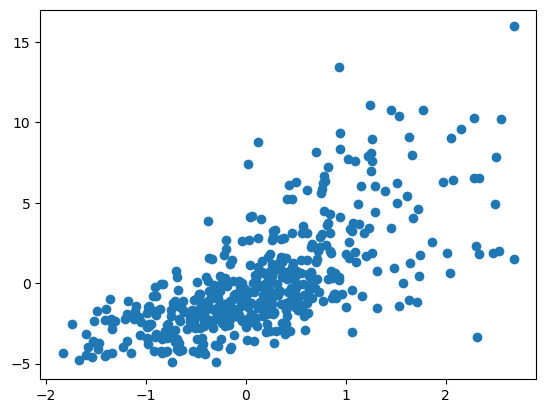

In [18]:
#scatter plot 
plt.scatter(ds_oni,pt['precip'])
plt.show()

In [19]:
#numpy correlation function
R = np.corrcoef(pt['precip'],ds_oni)
R

array([[1.        , 0.68191959],
       [0.68191959, 1.        ]])

In [20]:
#scipy correlation function 
(rvalue, pvalue) =  scipy.stats.pearsonr(ds_oni,pt['precip'])
rvalue

0.6819195937930848

In [21]:
pvalue

1.4645482121912831e-68

Text(1.0, 1.0, 'R= 0.68*')

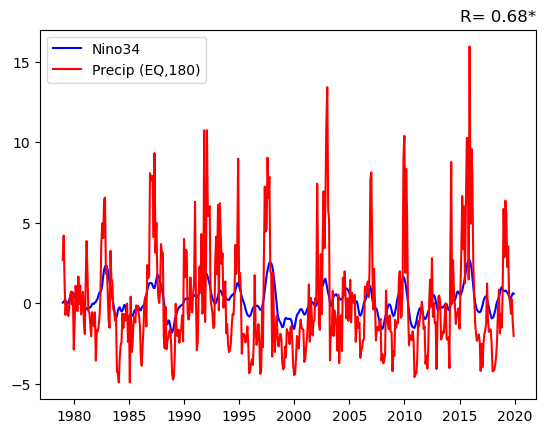

In [22]:
plt.plot(ds_oni['time'],ds_oni,'b')
plt.plot(pt['time'],pt['precip'],'r')
plt.legend(['Nino34','Precip (EQ,180)'])

rvalue_2 = round(rvalue, 2)
stuff_in_string = f"R= {rvalue_2}*"

#print(stuff_in_string)
plt.title(stuff_in_string,loc='right')

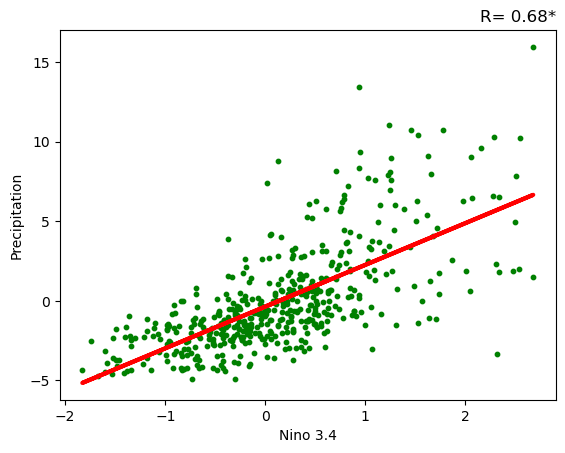

In [23]:
plt.scatter(ds_oni,pt['precip'], s=10, color="green")
plt.title(stuff_in_string,loc='right')

m, b = np.polyfit(ds_oni,pt['precip'], 1)
plt.plot(ds_oni, m*ds_oni + b, color="red",linewidth=3)
plt.xlabel("Nino 3.4")
plt.ylabel("Precipitation")

plt.show()

In [24]:
pip install "dask[complete]"

Note: you may need to restart the kernel to use updated packages.


In [25]:
#Method I: xarray
r_map = xr.corr(ds_oni,ds_anoms['precip'],dim = 'time')
r_map

<xarray.DataArray (lat: 72, lon: 144)>
array([[-0.0537149 , -0.06828387, -0.05305211, ..., -0.02416299,
        -0.08059757, -0.06473455],
       [-0.06207588, -0.06344423, -0.06396516, ..., -0.06803973,
        -0.09470741, -0.08590362],
       [-0.06646617, -0.06333132, -0.06755958, ..., -0.08694341,
        -0.07434858, -0.06826049],
       ...,
       [ 0.00620701,  0.00167196,  0.00645505, ..., -0.00839665,
        -0.00738842, -0.00678585],
       [-0.00249247, -0.00756896, -0.01013965, ..., -0.01647641,
        -0.01106096, -0.00560371],
       [-0.0183932 , -0.02959316, -0.0346237 , ..., -0.04737085,
        -0.02835331, -0.02533905]])
Coordinates:
  * lat      (lat) float32 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon      (lon) float32 1.25 3.75 6.25 8.75 11.25 ... 351.2 353.8 356.2 358.8

Text(0.5, 1.0, 'Correlation between Nino3.4 and Precipitation Anomalies')

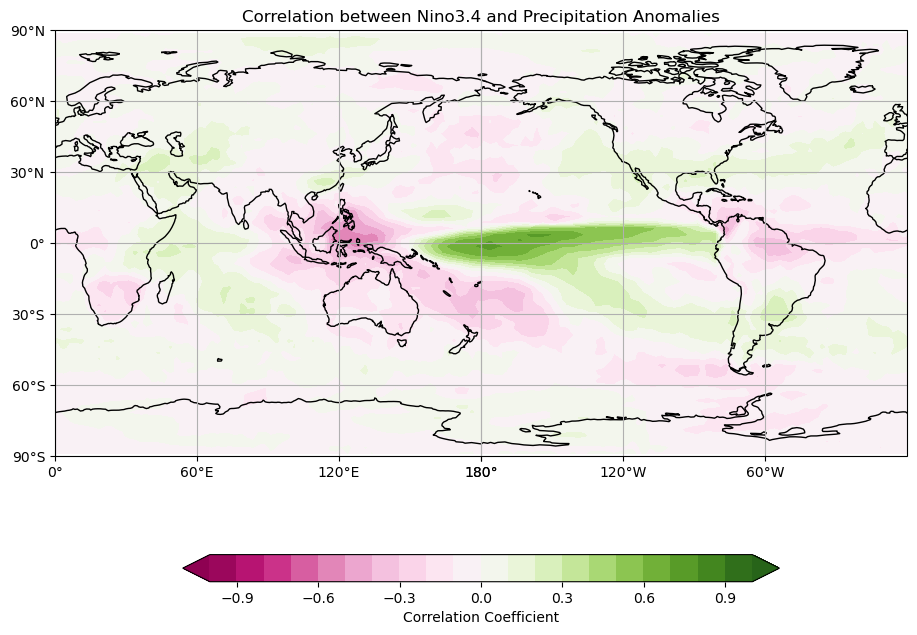

In [27]:
clevs=np.arange(-1,1.1,0.1)

fig = plt.figure(figsize=(11,8.5))

# Set the axes using the specified map projection
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

# Add cyclic point
data=r_map
data,lon=add_cyclic_point(r_map,coord=ds_anoms['lon'])

# Make a filled contour plot
cs=ax.contourf(lon,ds_anoms['lat'],
            data,clevs,
            transform=ccrs.PlateCarree(),
            cmap='PiYG',extend='both')

# Add coastlines
ax.coastlines()

# Add gridlines
ax.gridlines()

# Define the xticks for longtitude 
ax.set_xticks(np.arange(-180,181,60),crs=ccrs.PlateCarree())
lon_formatter=cticker.LongitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)

# Define ytick for latitude
ax.set_yticks(np.arange(-90,91,30),crs=ccrs.PlateCarree())
lat_formatter=cticker.LatitudeFormatter()
ax.yaxis.set_major_formatter(lat_formatter)

# Call colorbar
cbar=plt.colorbar(cs,orientation='horizontal',shrink=0.7,
                 label='Correlation Coefficient')

# Add title
plt.title('Correlation between Nino3.4 and Precipitation Anomalies')